# **EfficientNet Pre-trained Binary Model with Transformed Input**

In this notebook we test a pre-trained EfficientNet model to predict Animal vs Non-animal. <br>
For this, transformed/pre-processed images were used, which were generated with the help of the notebook `cleaner_routine.ipynb`.

## Libraries

In [ ]:
# Libraries
import pandas as pd

from deep.constants import METADATA_FILE, ROOT, SEED
from deep.models.model_runs import run_binary_model
from deep.models.model_defs import efficient_net

2025-04-26 07:53:28.656220: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-04-26 07:53:28.738774: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-04-26 07:53:28.764070: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-04-26 07:53:28.771373: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-04-26 07:53:28.850151: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting options
pd.set_option('display.max_rows', None)

## Data Loading

In [3]:
# Load the metadata
data = pd.read_csv(METADATA_FILE)

# Drop unnecessary columns for this problem
data.drop(columns=['phylum', 'family'], inplace=True)

In [8]:
data['is_animal'].value_counts()

is_animal
1    11138
0      846
Name: count, dtype: int64

## Data Preprocessing and Modelling

In [4]:
# Define seeds and path
binary_baseline_path = f"{ROOT}/models/binary_scores.json"

In [ ]:
# # DISCLAIMER: Uncomment this cell to create the transformed images

# # Create transformed images
# notebook_path = f'"{ROOT}/notebooks/preprocess_routine/cleaner_routine.ipynb"'
# %run $notebook_path

### Raw Model

I0000 00:00:1745650415.474315    4274 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745650415.655387    4274 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745650415.655598    4274 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1745650415.656938    4274 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

Loaded baseline score: 0.9291174411773682
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


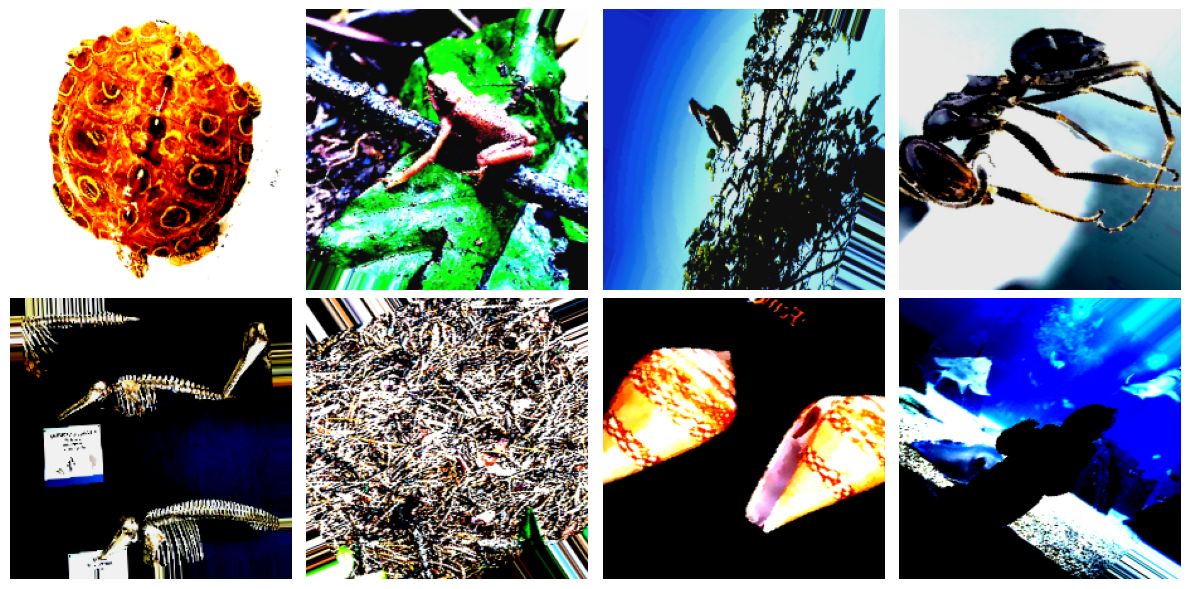

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10


I0000 00:00:1745650451.722412    4488 service.cc:146] XLA service 0x75e2a0002ed0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1745650451.722466    4488 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce MX350, Compute Capability 6.1
2025-04-26 07:54:12.418627: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-04-26 07:54:15.071700: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90100
2025-04-26 07:54:26.434053: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allocator (GPU_0_bfc) ran out of memory trying to allocate 1.16GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.
2025-04-26 07:54:35.201165: W external/local_tsl/tsl/framework/bfc_allocator.cc:291] Allo

 77/128 ━━━━━━━━━━━━━━━━━━━━ 3:57 5s/step - accuracy: 0.7317 - auc: 0.5691 - loss: 0.5919 - precision: 0.9344 - recall: 0.7622

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 770s 6s/step - accuracy: 0.7895 - auc: 0.5806 - loss: 0.5300 - precision: 0.9355 - recall: 0.8289 - val_accuracy: 0.9298 - val_auc: 0.7285 - val_loss: 0.3009 - val_precision: 0.9316 - val_recall: 0.9978 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 677s 5s/step - accuracy: 0.9330 - auc: 0.6968 - loss: 0.2348 - precision: 0.9342 - recall: 0.9981 - val_accuracy: 0.9333 - val_auc: 0.7214 - val_loss: 0.3116 - val_precision: 0.9361 - val_recall: 0.9963 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 682s 5s/step - accuracy: 0.9288 - auc: 0.7107 - loss: 0.2435 - precision: 0.9296 - recall: 0.9985 - val_accuracy: 0.9354 - val_auc: 0.7769 - val_loss: 0.2310 - val_precision: 0.9449 - val_recall: 0.9880 - learning_rate: 0.0010
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 680s 5s/step - accuracy: 0.9315 - auc: 0.7111 - loss: 0.2351 - precision: 0.9331 - recall: 0.9976 - val_accuracy: 0.7491 - val_auc: 0.7755 - val_loss: 0.5708 - val_precis

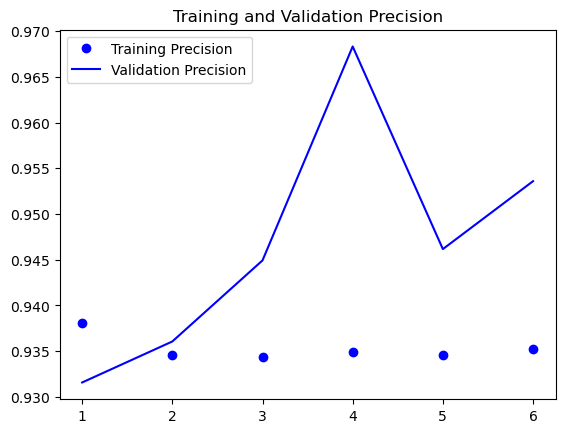

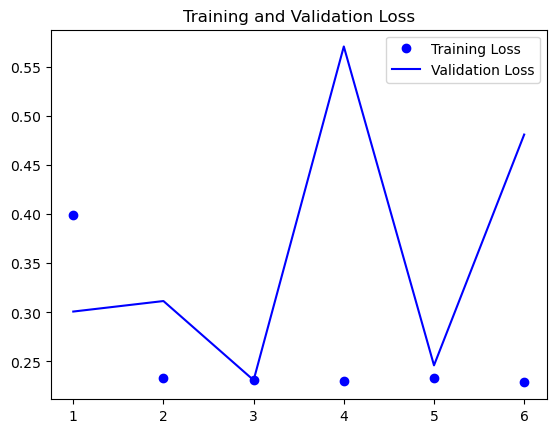

Saved current model as new baseline


In [5]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
)

This model with the transformed images proved to yield better precision results than with the original images.

### Model with Regularization

In this section we add L2 regularization to our model and test if it improves the model

Loaded baseline score: 0.9449213147163391
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


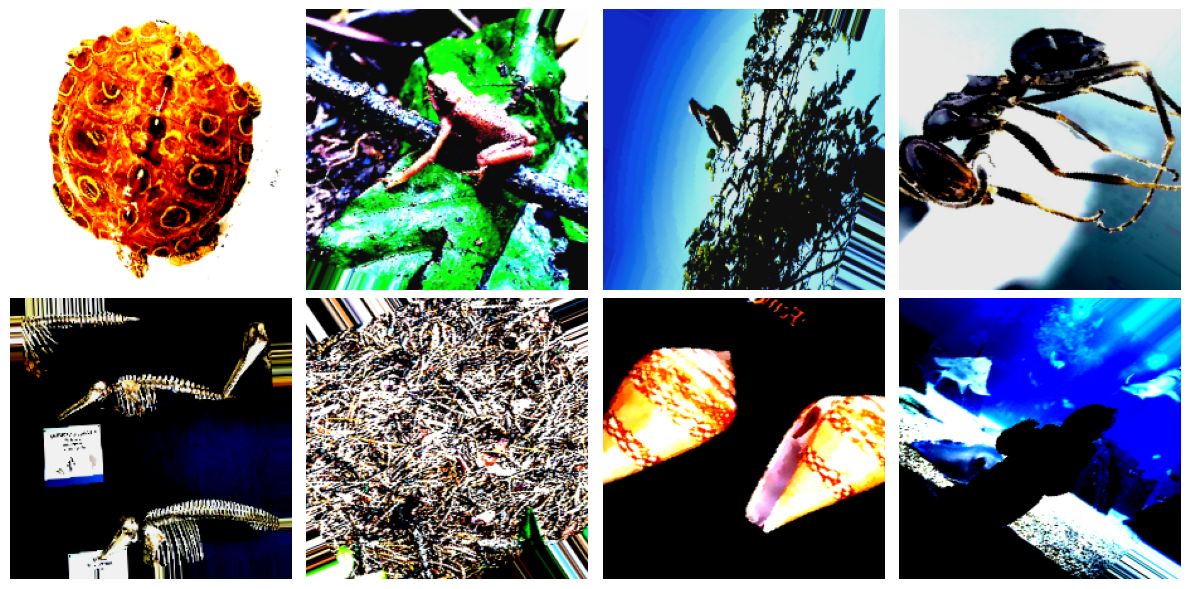

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
 12/128 ━━━━━━━━━━━━━━━━━━━━ 8:31 4s/step - accuracy: 0.5651 - auc_1: 0.5590 - loss: 0.8906 - precision: 0.9325 - recall: 0.5731

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 741s 6s/step - accuracy: 0.8008 - auc_1: 0.6158 - loss: 0.6534 - precision: 0.9352 - recall: 0.8434 - val_accuracy: 0.9319 - val_auc_1: 0.7688 - val_loss: 0.2820 - val_precision: 0.9323 - val_recall: 0.9993 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 684s 5s/step - accuracy: 0.9327 - auc_1: 0.6573 - loss: 0.2705 - precision: 0.9342 - recall: 0.9981 - val_accuracy: 0.9291 - val_auc_1: 0.7542 - val_loss: 0.2508 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 692s 5s/step - accuracy: 0.9305 - auc_1: 0.6811 - loss: 0.2518 - precision: 0.9307 - recall: 0.9997 - val_accuracy: 0.9291 - val_auc_1: 0.7563 - val_loss: 0.2633 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9320 - auc_1: 0.6496 - loss: 0.2429 - precision: 0.9321 - recall: 0.9999
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00050

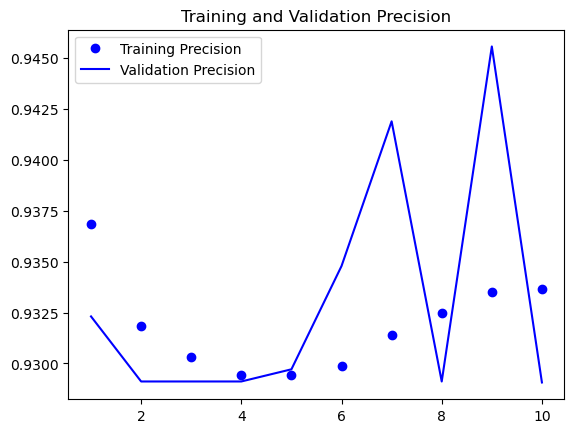

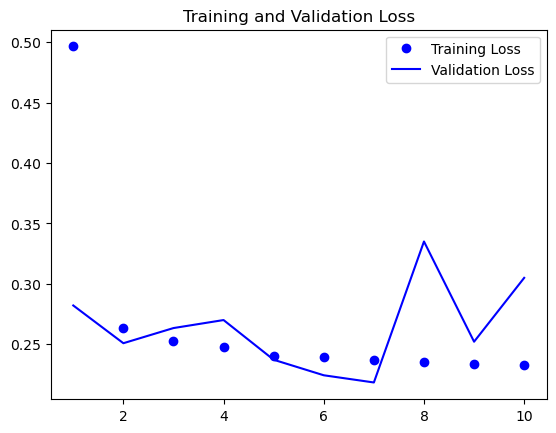

Current model not better than baseline


In [6]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=True
        ,dropout=False
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
)

Regularization did not improve the model.

### Model with Dropout

In this section we add a dropout layer to the model and test if it improves the results.

Loaded baseline score: 0.9449213147163391
Found 8148 validated image filenames belonging to 2 classes.
Found 1439 validated image filenames belonging to 2 classes.
Found 2397 validated image filenames belonging to 2 classes.


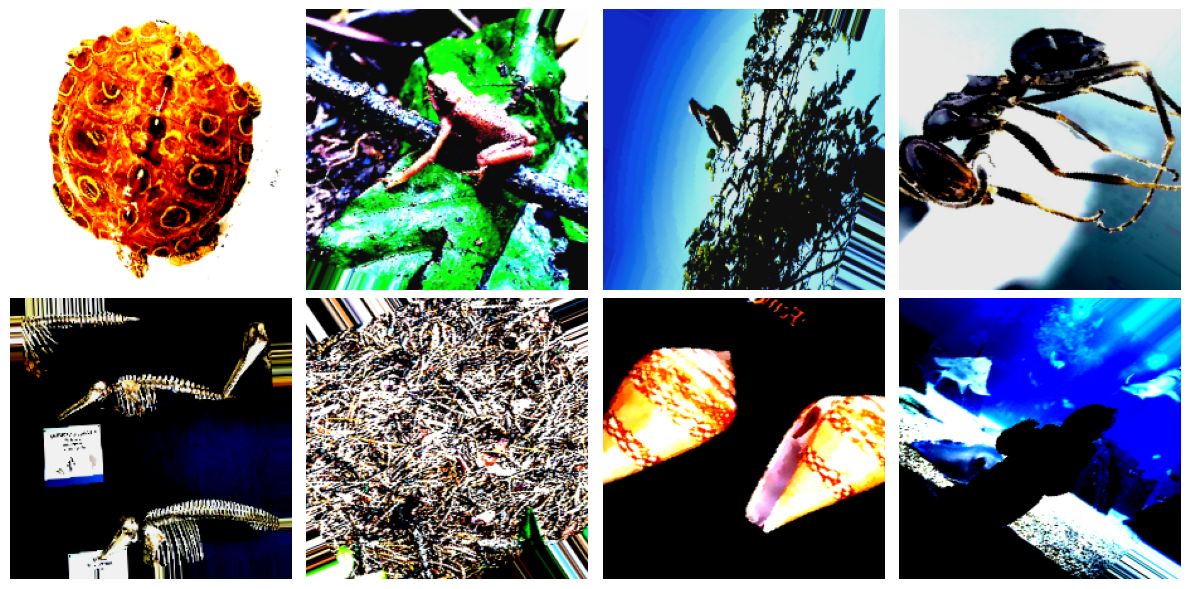

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
  3/128 ━━━━━━━━━━━━━━━━━━━━ 5:08 2s/step - accuracy: 0.5391 - auc_2: 0.5341 - loss: 0.8956 - precision: 0.9431 - recall: 0.5343   

/home/shadybea/anaconda3/envs/dl/lib/python3.11/site-packages/PIL/Image.py:3402: DecompressionBombWarning: Image size (115600000 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(


128/128 ━━━━━━━━━━━━━━━━━━━━ 736s 6s/step - accuracy: 0.7306 - auc_2: 0.5819 - loss: 0.6082 - precision: 0.9387 - recall: 0.7602 - val_accuracy: 0.9368 - val_auc_2: 0.7631 - val_loss: 0.3792 - val_precision: 0.9463 - val_recall: 0.9880 - learning_rate: 0.0010
Epoch 2/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 684s 5s/step - accuracy: 0.9255 - auc_2: 0.5627 - loss: 0.2745 - precision: 0.9311 - recall: 0.9934 - val_accuracy: 0.9333 - val_auc_2: 0.7666 - val_loss: 0.2608 - val_precision: 0.9361 - val_recall: 0.9963 - learning_rate: 0.0010
Epoch 3/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 686s 5s/step - accuracy: 0.9312 - auc_2: 0.6062 - loss: 0.2481 - precision: 0.9317 - recall: 0.9993 - val_accuracy: 0.9291 - val_auc_2: 0.7585 - val_loss: 0.2688 - val_precision: 0.9291 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/10
128/128 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.9298 - auc_2: 0.6423 - loss: 0.2480 - precision: 0.9310 - recall: 0.9983
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.00050

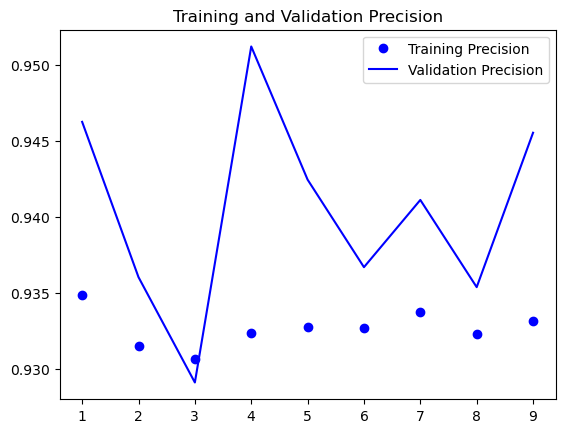

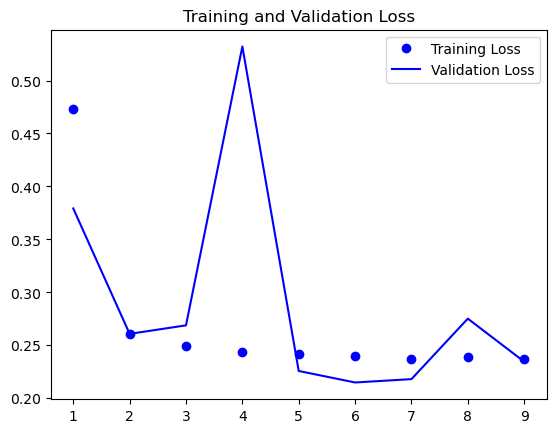

Current model not better than baseline


In [7]:
run_binary_model(
    file_path=binary_baseline_path
    ,data=data
    ,seed=SEED
    ,model=efficient_net(
        regularizer=False
        ,dropout=True
    )
    ,loss='crossentropy'
    ,epochs=10
    ,type='transformed'
)

The dropout layer did not improve the model.

Now, we will attempt to fix the class imbalance based on the transformed images and recheck the model.